# Tuning and Model Evaluation

## Used libraries

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
from sklearn import clone
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, LearningCurveDisplay, learning_curve, ValidationCurveDisplay, validation_curve
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel, f_classif

C:\Users\Hassan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading data

In [3]:
train = pd.read_parquet('../train_extended.parquet')
test = pd.read_parquet('../test_extended.parquet')

x_train, y_train = train.drop('RET', axis=1), train['RET']

## Feature pre-selection

Below the differents selection of feature done on the ``notebook_feature_selection.ipynb``

In [ ]:
fi = pd.read_hdf('features_statistics.h5', key='fi')
mi = pd.read_hdf('features_statistics.h5', key='mi')
fwd_corr = pd.read_hdf('features_statistics.h5', key='fwd_corr')
# shapval = pd.read_hdf('features_statistics.h5', key='shap_values')


Below my cherry-pick selection of features based on multiple hours of cooking (works better than the previous feature selection)

In [ ]:
ret_cols = ['RET_%d' % i for i in range(1, 6)]
volume_cols = ['VOLUME_%d' % i for i in range(1, 6)]
cat_cols = ['DATE','STOCK','INDUSTRY','INDUSTRY_GROUP','SECTOR','SUB_INDUSTRY']
# using regex to filter temporal and sectorial aggregation features
DATE_cols = x_train.filter(regex='\w+_\d+_DATE_\w+').columns.tolist()
SECTOR_cols = x_train.filter(regex='\w+_\d+_SECTOR_DATE_\w+').columns.tolist()
INDUSTRY_GROUP_cols = x_train.filter(regex='\w+_\d+_INDUSTRY_GROUP_DATE_\w+').columns.tolist()
INDUSTRY_cols = x_train.filter(regex='\w+_\d+_INDUSTRY_DATE_\w+').columns.tolist()
SUB_INDUSTRY_cols = x_train.filter(regex='\w+_\d+_SUB_INDUSTRY_DATE_\w+').columns.tolist()
# other patterns to filter the others features
ROLLING_STATS_cols = x_train.columns[x_train.columns.str.endswith('D')].tolist()
WEEK_cols = x_train.columns[x_train.columns.str.contains('WEEK')].tolist()
INDICATOR_cols = x_train.columns[x_train.columns.str.endswith('VOLUME') | x_train.columns.str.endswith('RET') | x_train.columns.str.contains('RSI') | x_train.columns.str.contains('ADL')].tolist()
VOLATILITY_cols = x_train.columns[x_train.columns.str.contains('VOLATILITY')].tolist()

Here I'm testing various combinations of subsets to find the best recipe.

In [5]:
features = pd.read_hdf('features_selection.h5', key='features_s').to_list()
len(features), features

(29,
 ['RET_1',
  'VOLUME_1',
  'RET_3_SECTOR_DATE_std',
  'Range_RET_10D',
  'RSI_15_SECTOR_DATE',
  'RET_1_DATE_skew',
  'VOLUME_5_DATE_max',
  'RET_1_SECTOR_DATE_median',
  'RET_5_DATE_median',
  'RET_SECTOR_DATE_VOLATILITY_15',
  'ADL_15_SECTOR_DATE',
  'RET_3_DATE_max',
  'VOLUME_1_DATE_median',
  'VOLATILITY_RET',
  'Std_RET_10D',
  'RSI_20_SECTOR_DATE',
  'RET_5_DATE_mean',
  'RET_1_SECTOR_DATE_mean',
  'Range_RET_20D',
  'RET_SECTOR_DATE_VOLATILITY_5',
  'RET_5_SECTOR_DATE_std',
  'VOLUME_2_DATE_min',
  'RET_SECTOR_DATE_VOLATILITY_20',
  'Momentum_RET_10D',
  'std_RET_WEEK_1',
  'VOLUME_5_SECTOR_DATE_skew',
  'RET_15_SECTOR_DATE_Momentum',
  'RET_3_DATE_mean',
  'VOLUME_SECTOR_DATE_VOLATILITY_15'])

## Fine-Tuning

In [5]:
# optuna hyperparameter optimization

def objective(trial):
    # Define the hyperparameters to optimize
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 400),
        'max_depth': trial.suggest_int('max_depth', 5, 8),
    }
    # Define the model
    clf =  RandomForestClassifier(**params, n_jobs=-1)
    # Define the score
    score = cross_val_score(clf, x_train[features], y_train, cv=3, scoring='accuracy').mean()
    return score

# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

# Print the best set of hyperparameters
print('Best hyperparameters: ', study.best_params)
# Print the corresponding performance
print('Best performance: ', study.best_value)


[I 2025-02-21 01:42:41,463] A new study created in memory with name: no-name-ae016db8-a720-474d-84b6-2e918f3d55e0


Best trial: 0. Best value: 0.519348:   5%|▌         | 1/20 [01:41<32:16, 101.94s/it]

[I 2025-02-21 01:44:23,648] Trial 0 finished with value: 0.5193476458823784 and parameters: {'n_estimators': 370, 'max_depth': 8}. Best is trial 0 with value: 0.5193476458823784.


Best trial: 1. Best value: 0.519773:  10%|█         | 2/20 [02:57<25:50, 86.16s/it] 

[I 2025-02-21 01:45:38,787] Trial 1 finished with value: 0.5197733939063048 and parameters: {'n_estimators': 315, 'max_depth': 7}. Best is trial 1 with value: 0.5197733939063048.


...

[I 2025-02-21 01:59:02,206] Trial 17 finished with value: 0.5209399971605423 and parameters: {'n_estimators': 206, 'max_depth': 6}. Best is trial 15 with value: 0.5211131836782132.


Best trial: 15. Best value: 0.521113:  95%|█████████▌| 19/20 [17:02<00:42, 42.13s/it]

[I 2025-02-21 01:59:43,796] Trial 18 finished with value: 0.5208654299201774 and parameters: {'n_estimators': 193, 'max_depth': 6}. Best is trial 15 with value: 0.5211131836782132.


Best trial: 15. Best value: 0.521113: 100%|██████████| 20/20 [17:51<00:00, 53.60s/it]

[I 2025-02-21 02:00:33,662] Trial 19 finished with value: 0.5199754445485102 and parameters: {'n_estimators': 209, 'max_depth': 7}. Best is trial 15 with value: 0.5211131836782132.
Best hyperparameters:  {'n_estimators': 198, 'max_depth': 6}
Best performance:  0.5211131836782132


### Validation and Learning Curve

In [ ]:
# Validation and learning curve plot 

# Define the model with the best hyperparameters
clf = RandomForestClassifier(**study.best_params, n_jobs=-1, verbose=1)
# Define the learning curve
train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(clf, x_train[features], y_train, cv=3, train_sizes=np.linspace(0.1, 1.0, 3), return_times=True)


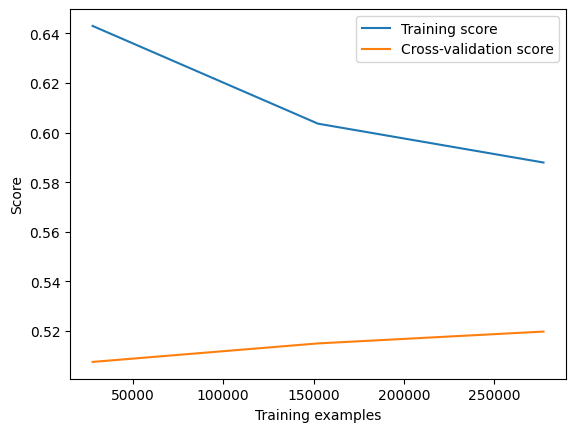

In [22]:

# Plot the learning curve
fig, ax = plt.subplots()
ax.plot(train_sizes, np.mean(train_scores, axis=1), label='Training score')
ax.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-validation score')
ax.set_xlabel('Training examples')
ax.set_ylabel('Score')
ax.legend()
plt.show()


In [ ]:

# Define the validation curve
param_range = np.arange(200, 600, 5)
train_scores, test_scores = validation_curve(clf, x_train[features], y_train, param_name='n_estimators', param_range=param_range, cv=4)

# Plot the validation curve
fig, ax = plt.subplots()
ax.plot(param_range, np.mean(train_scores, axis=1), label='Training score')
ax.plot(param_range, np.mean(test_scores, axis=1), label='Cross-validation score')
ax.set_xlabel('Number of trees')
ax.set_ylabel('Score')
ax.legend()
plt.show()



## Model and local score

A Random Forest (RF) model is chosen for the Benchmark. We consider a large number of tree with a quiet small depth. The missing values are simply filled with 0. A KFold is done on the dates (using `DATE`) for a local scoring of the model. 

**Ideas of improvements**: Tune the RF hyperparameters, deal with the missing values, change the features, consider another model, ...

In [6]:
# Final model

X_train = train[features]

# Define the model with the best hyperparameters
tuned_model = RandomForestClassifier(**study.best_params, n_jobs=-1)

# A quiet large number of trees with low depth to prevent overfits
train_dates = train['DATE'].unique()
test_dates = test['DATE'].unique()

n_splits = 4
scores = []
models = []

splits = KFold(n_splits=n_splits, random_state=0,
               shuffle=True).split(train_dates) # Generates the splits of the indexes to use as train / test

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = train['DATE'].isin(local_train_dates)
    local_test_ids = train['DATE'].isin(local_test_dates)

    X_local_train = X_train.loc[local_train_ids]
    y_local_train = y_train.loc[local_train_ids]
    X_local_test = X_train.loc[local_test_ids]
    y_local_test = y_train.loc[local_test_ids]

    model = clone(tuned_model)
    model.fit(X_local_train, y_local_train.values.reshape(-1))

    y_local_pred = model.predict_proba(X_local_test)[:, 1]
    
    sub = train.loc[local_test_ids].copy()
    sub['pred'] = y_local_pred
    y_local_pred = sub.groupby('DATE')['pred'].transform(lambda x: x > x.median()).values

    models.append(model)
    score = accuracy_score(y_local_test, y_local_pred)
    scores.append(score)
    print(f"Fold {i+1} - Accuracy: {score* 100:.2f}%")

mean = np.mean(scores)*100
std = np.std(scores)*100
u = (mean + std)
l = (mean - std)
print(f'Accuracy: {mean:.2f}% [{l:.2f} ; {u:.2f}] (+- {std:.2f})')

Fold 1 - Accuracy: 53.04%
Fold 2 - Accuracy: 51.76%
Fold 3 - Accuracy: 52.59%
Fold 4 - Accuracy: 52.86%
Accuracy: 52.56% [52.07 ; 53.06] (+- 0.49)


In [7]:
# cross validation score with predict built-in method to compare with the previous prediction method
score = cross_val_score(tuned_model, X_train, y_train, cv=4, scoring='accuracy', n_jobs=-1, verbose=1)

print("Cross-validation score with predict built-in method")
for i in range(len(score)):
    print(f'Fold {i+1} - Accuracy: {score[i]*100:.2f}%')
print(f'Accuracy: {np.mean(score)*100:.2f}% (+- {np.std(score)*100:.2f})')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Cross-validation score with predict built-in method
Fold 1 - Accuracy: 53.29%
Fold 2 - Accuracy: 52.35%
Fold 3 - Accuracy: 51.27%
Fold 4 - Accuracy: 51.00%
Accuracy: 51.98% (+- 0.91)


[Parallel(n_jobs=-1)]: Done   4 out of   4 | elapsed:  1.2min finished


<Axes: >

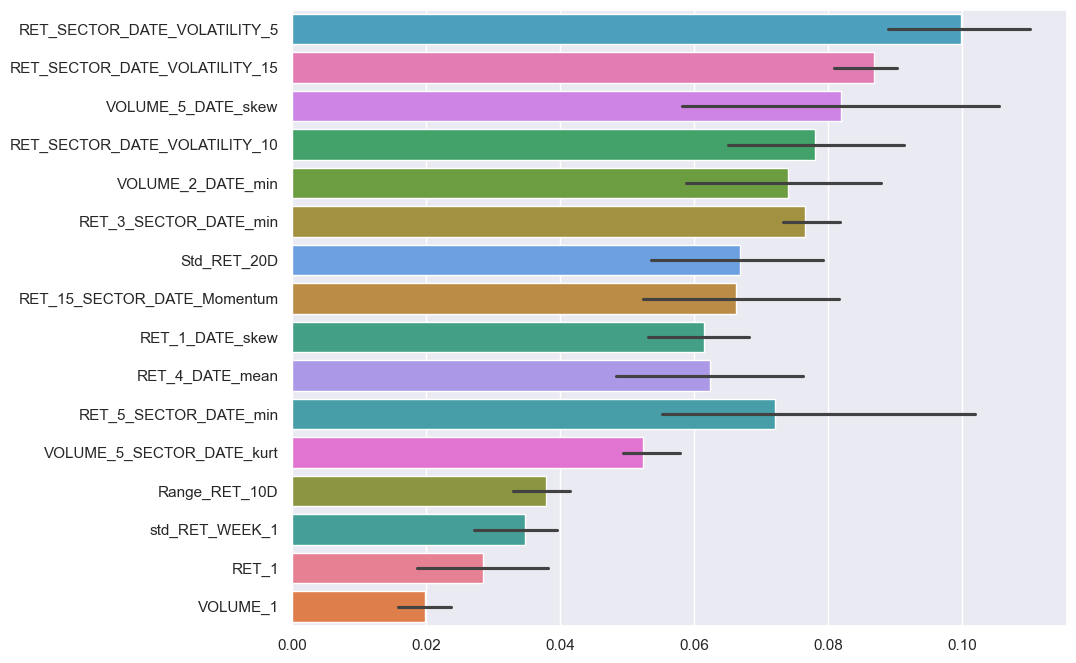

In [9]:
feature_importances = pd.DataFrame([model.feature_importances_ for model in models], columns=features)

sns.set(rc={'figure.figsize':(10,len(features)//2)})
sns.barplot(data=feature_importances, orient='h', order=feature_importances.median().sort_values(ascending=False).index )

## Generate the submission

The same parameters of the RF model are considered. With that we build a new RF model on the entire `train` dataset. The predictions are saved in a `.csv` file.

In [10]:
target = 'RET'
X_test = test[features]

model = clone(tuned_model)
model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)[:, 1]

sub = test.copy()
sub['pred'] = y_pred
y_pred = sub.groupby('DATE')['pred'].transform(
    lambda x: x > x.median()).values

submission = pd.Series(y_pred)
submission.index = test.index
submission.name = target

submission.to_csv('submission.csv', index=True, header=True)

## Draft Zone

### Defining our ML Pipeline and the GridSearchCV procedure
- Throug a GridSearchCV we aim to compare the performance of different Imputations methods and Feature Selections
- For that we create a pipeline to embbed all the successive steps of the data transformation in one estimator
- Warning to use Catboost in a pipeline : 
    - https://medium.com/analytics-vidhya/combining-scikit-learn-pipelines-with-catboost-and-dask-part-2-9240242966a7
    - https://stackoverflow.com/questions/56742441/



In [ ]:

model = Pipeline([
    ('feature_selection', 'passthrough'),
    ('classify', 'passthrough')
])

# Define the parameter grid for GridSearchCV
param_grid = [
    {
        'feature_selection': [SelectFromModel(RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1))],
        'feature_selection__max_features': [75],
        'classify': [RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1), 
                    CatBoostClassifier(depth=6, iterations=1000,  early_stopping_rounds=100, task_type="GPU", devices='0', verbose=0)]
    },

    {
        'feature_selection': [SelectFromModel(CatBoostClassifier(depth=8, iterations=1000,  early_stopping_rounds=50, task_type="GPU", devices='0', verbose=0))],
        'feature_selection__max_features': [75],
        'classify': [RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1), 
                    CatBoostClassifier(depth=6, iterations=1000,  early_stopping_rounds=100, task_type="GPU", devices='0', verbose=0)]
    },
    
    {
        'feature_selection': [SelectKBest()],
        'feature_selection__score_func': [mutual_info_classif, f_classif],
        'feature_selection__k': [75],
        'classify': [RandomForestClassifier(n_estimators=500, max_depth=8, n_jobs=-1), 
                    CatBoostClassifier(depth=8, iterations=1000,  early_stopping_rounds=100, task_type="GPU", devices='0', verbose=0)],
    }
]

# define the GridSearchCV
grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', verbose=3, n_jobs=1, error_score='raise')

# fit the GridSearchCV
grid.fit(x_train, y_train)

# get the parameters of models sorted by ranked score of accuracy
results = pd.DataFrame(grid.cv_results_)
results.sort_values(by='rank_test_score', inplace=True)
results